# PHÁT HIỆN TIN GIẢ - MẠNG GRU
Dataset: Fake_News_Detection_Dataset.csv

Mục tiêu: Xây dựng mạng GRU (Gated Recurrent Unit) để phân loại bài báo là tin thật hoặc tin giả.

- Đầu ra: 1 neuron (xác suất bài báo là tin giả)
- Loss: BCEWithLogitsLoss (Binary Cross Entropy)
- Activation: Sigmoid
- Ưu điểm GRU: Đơn giản hơn LSTM (2 cổng thay vì 3), huấn luyện nhanh hơn, hiệu quả tương đương

## a. Tiền xử lý dữ liệu & Thiết lập dữ liệu

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import re
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
df = pd.read_csv('Fake_News_Detection_Dataset.csv')
print(f'Số mẫu: {len(df)}')
print(f'Phân bố nhãn:\n{df["label"].value_counts()}')
df = df.dropna(subset=['text', 'label'])
print(f'Số mẫu sau xử lý null: {len(df)}')

Số mẫu: 3340
Phân bố nhãn:
label
0    1670
1    1670
Name: count, dtype: int64
Số mẫu sau xử lý null: 3340


### Tokenization & Padding

In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)

def build_vocab(texts, max_words=20000):
    word_counts = Counter()
    for text in texts:
        word_counts.update(text.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.most_common(max_words - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df['text_clean'], max_words=20000)
print(f'Kích thước từ điển: {len(vocab)}')

Kích thước từ điển: 20000


In [4]:
MAX_LEN = 200

def text_to_indices(text, vocab, max_len):
    tokens = text.split()
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    if len(indices) < max_len:
        indices += [vocab['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

X = np.array([text_to_indices(t, vocab, MAX_LEN) for t in df['text_clean']])
y = df['label'].values.astype(np.float32)

print(f'Input shape: {X.shape}')
print(f'Label shape: {y.shape}')

Input shape: (3340, 200)
Label shape: (3340,)


### Chia dữ liệu Train / Validation / Test

In [5]:
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 2338 | Val: 501 | Test: 501


In [6]:
class FakeNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = FakeNewsDataset(X_train, y_train)
val_dataset = FakeNewsDataset(X_val, y_val)
test_dataset = FakeNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## b. Xây dựng kiến trúc GRU & Huấn luyện

In [7]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes=1, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)            # (batch, seq_len, embed_dim)
        output, hidden = self.gru(embedded)     # hidden: (num_layers, batch, hidden_size)
        last_output = output[:, -1, :]          # (batch, hidden_size)
        out = self.dropout(last_output)
        out = self.fc(out)
        return out.squeeze(1)

print('Mô hình GRU đã định nghĩa.')

Mô hình GRU đã định nghĩa.


In [8]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 64
HIDDEN_SIZE = 32
NUM_LAYERS = 2
LEARNING_RATE = 0.001
NUM_EPOCHS = 25

model = GRUClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Tổng tham số: {total_params:,}')

GRUClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (gru): GRU(64, 32, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Tổng tham số: 1,295,777


In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Huấn luyện mô hình

In [10]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print('\nHuấn luyện hoàn tất!')

Epoch [1/25]  Train Loss: 0.6865 | Train Acc: 0.5466 | Val Loss: 0.6689 | Val Acc: 0.5968
Epoch [5/25]  Train Loss: 0.4438 | Train Acc: 0.8169 | Val Loss: 0.6082 | Val Acc: 0.7146
Epoch [10/25]  Train Loss: 0.3376 | Train Acc: 0.8935 | Val Loss: 0.5690 | Val Acc: 0.7685
Epoch [15/25]  Train Loss: 0.2900 | Train Acc: 0.8892 | Val Loss: 0.5000 | Val Acc: 0.8104
Epoch [20/25]  Train Loss: 0.1542 | Train Acc: 0.9316 | Val Loss: 0.4236 | Val Acc: 0.8443
Epoch [25/25]  Train Loss: 0.0914 | Train Acc: 0.9666 | Val Loss: 0.4853 | Val Acc: 0.8463

Huấn luyện hoàn tất!


## c. Đánh giá, Dự đoán & Lời giải

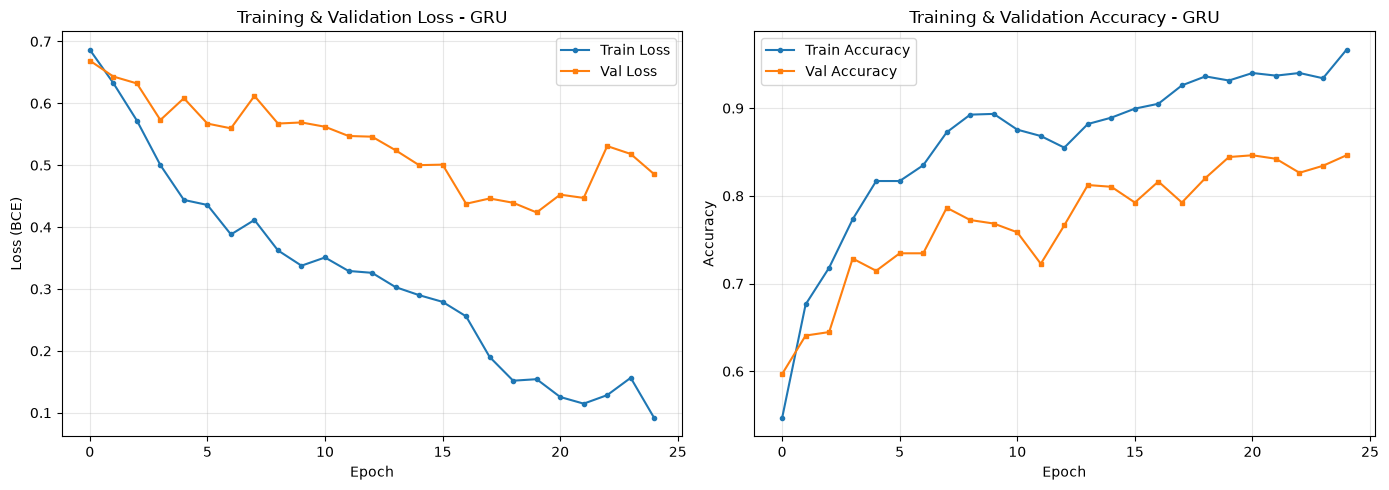

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training & Validation Loss - GRU')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(val_accuracies, label='Val Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy - GRU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print('=' * 50)
print('         KẾT QUẢ ĐÁNH GIÁ - GRU')
print('=' * 50)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('=' * 50)
print('\nConfusion Matrix:')
print(confusion_matrix(test_labels, test_preds))
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=['Tin thật (0)', 'Tin giả (1)']))

         KẾT QUẢ ĐÁNH GIÁ - GRU
Accuracy:  0.8882
Precision: 0.9153
Recall:    0.9035
F1-Score:  0.9094

Confusion Matrix:
[[164  26]
 [ 30 281]]

Classification Report:
              precision    recall  f1-score   support

Tin thật (0)       0.85      0.86      0.85       190
 Tin giả (1)       0.92      0.90      0.91       311

    accuracy                           0.89       501
   macro avg       0.88      0.88      0.88       501
weighted avg       0.89      0.89      0.89       501



### Dự đoán mẫu thực tế

In [13]:
model.eval()
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print('=' * 80)
print('DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - GRU')
print('=' * 80)
print(f'{"Mẫu":<5} | {"Nhãn thực":<10} | {"Nhãn dự đoán":<12} | {"Xác suất":<10} | {"Kết quả":<8}')
print('-' * 80)

label_map = {0: 'Thật', 1: 'Giả'}
for i, idx in enumerate(sample_indices):
    x_input = torch.tensor([X_test[idx]], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(x_input)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob >= 0.5 else 0
    actual = int(y_test[idx])
    result = 'Đúng' if pred == actual else 'Sai'
    print(f'{i+1:<5} | {label_map[actual]:<10} | {label_map[pred]:<12} | {prob:.4f}     | {result}')

print('=' * 80)

DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - GRU
Mẫu   | Nhãn thực  | Nhãn dự đoán | Xác suất   | Kết quả 
--------------------------------------------------------------------------------
1     | Giả        | Giả          | 0.9959     | Đúng
2     | Thật       | Thật         | 0.0101     | Đúng
3     | Giả        | Giả          | 0.9825     | Đúng
4     | Thật       | Thật         | 0.0117     | Đúng
5     | Thật       | Giả          | 0.6236     | Sai
6     | Giả        | Giả          | 0.9978     | Đúng
7     | Giả        | Thật         | 0.0510     | Sai
8     | Thật       | Thật         | 0.0066     | Đúng
9     | Giả        | Giả          | 0.9926     | Đúng
10    | Giả        | Giả          | 0.9437     | Đúng


C:\Users\Zekas\AppData\Local\Temp\ipykernel_26724\1421581144.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  x_input = torch.tensor([X_test[idx]], dtype=torch.long).to(device)


In [14]:
sample_idx = len(X_test) - 1
x_input = torch.tensor([X_test[sample_idx]], dtype=torch.long).to(device)

with torch.no_grad():
    output = model(x_input)
    prob = torch.sigmoid(output).item()
    pred = 1 if prob >= 0.5 else 0

actual = int(y_test[sample_idx])
label_map = {0: 'Thật', 1: 'Giả'}

print('\n' + '=' * 60)
print('CHI TIẾT MẪU DỰ ĐOÁN - GRU')
print('=' * 60)
print(f'Nhãn thực tế:   {label_map[actual]} ({actual})')
print(f'Nhãn dự đoán:   {label_map[pred]} ({pred})')
print(f'Xác suất tin giả: {prob:.4f}')
print(f'Chênh lệch:     {abs(prob - actual):.4f}')
print(f'Kết quả:        {"ĐÚNG" if pred == actual else "SAI"}')
print('=' * 60)


CHI TIẾT MẪU DỰ ĐOÁN - GRU
Nhãn thực tế:   Giả (1)
Nhãn dự đoán:   Giả (1)
Xác suất tin giả: 0.9952
Chênh lệch:     0.0048
Kết quả:        ĐÚNG


## So sánh GRU với LSTM

| Đặc điểm | GRU | LSTM |
|-----------|-----|------|
| Số cổng | 2 (Update, Reset) | 3 (Forget, Input, Output) |
| Trạng thái | Chỉ có Hidden State | Hidden State + Cell State |
| Tham số | Ít hơn (~30%) | Nhiều hơn |
| Tốc độ huấn luyện | Nhanh hơn | Chậm hơn |
| Hiệu quả | Tương đương LSTM trên nhiều tác vụ | Tốt hơn trên chuỗi rất dài |